In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ----------------------------
# Dataset Path
# ----------------------------
DATASET_PATH = "data/train"

classes = ["dark", "normal", "bright"]

results = []

print("Analyzing all training images...\n")

for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    for file in tqdm(os.listdir(folder), desc=cls):

        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        # ----------------------------
        # RGB -> Gray
        # ----------------------------
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ----------------------------
        # HSV
        # ----------------------------
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        value = hsv[:, :, 2]

        # ----------------------------
        # Statistics
        # ----------------------------

        mean_gray = np.mean(gray)

        std_gray = np.std(gray)

        min_gray = np.min(gray)

        max_gray = np.max(gray)

        median_gray = np.median(gray)

        mean_value = np.mean(value)

        std_value = np.std(value)

        # Percentage of dark pixels

        dark_ratio = np.mean(gray < 50)

        # Percentage of bright pixels

        bright_ratio = np.mean(gray > 200)

        results.append({

            "class": cls,

            "mean_gray": mean_gray,

            "median_gray": median_gray,

            "std_gray": std_gray,

            "min_gray": min_gray,

            "max_gray": max_gray,

            "mean_value": mean_value,

            "std_value": std_value,

            "dark_ratio": dark_ratio,

            "bright_ratio": bright_ratio

        })

# ----------------------------
# DataFrame
# ----------------------------

df = pd.DataFrame(results)

print("\nAnalysis Complete!\n")

summary = df.groupby("class").agg({

    "mean_gray": ["mean", "std"],

    "median_gray": ["mean"],

    "std_gray": ["mean"],

    "mean_value": ["mean"],

    "std_value": ["mean"],

    "dark_ratio": ["mean"],

    "bright_ratio": ["mean"]

})

display(summary)

Analyzing all training images...



bright: 100%|██████████| 500/500 [00:05<00:00, 91.97it/s]


Analysis Complete!



mean_gray            median_gray   std_gray mean_value  std_value  \
             mean        std        mean       mean       mean       mean   
class                                                                       
bright  80.278295  18.939502      78.626  42.254326  87.160791  42.815635   
dark    64.031197  18.317973      58.291  39.622865  70.297366  40.565973   
normal  81.569505  18.658174      80.640  41.293134  88.478030  41.777970   

       dark_ratio bright_ratio  
             mean         mean  
class                           
bright   0.299378     0.007205  
dark     0.453221     0.004512  
normal   0.281156     0.009035

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

### cell 2 - Boxplot - Mean Gray Intensity

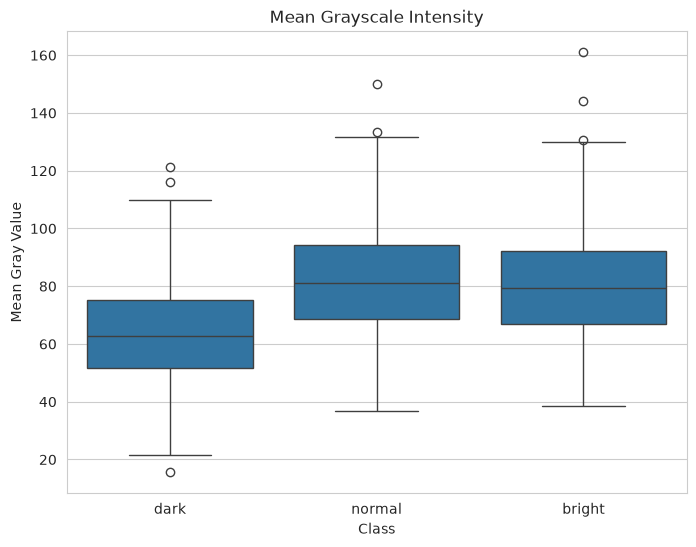

In [3]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="mean_gray"
)

plt.title("Mean Grayscale Intensity")
plt.xlabel("Class")
plt.ylabel("Mean Gray Value")

plt.show()

### Cell 3: Boxplot - HSV Value

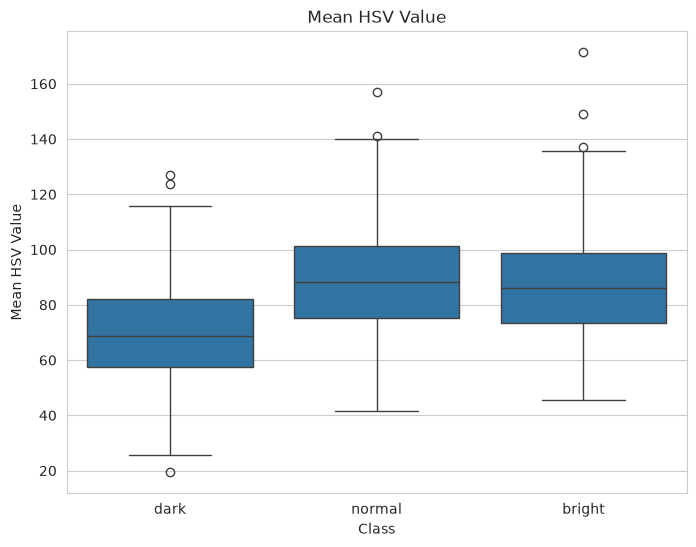

In [4]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="mean_value"
)

plt.title("Mean HSV Value")
plt.xlabel("Class")
plt.ylabel("Mean HSV Value")

plt.show()

### Cell 4: Boxplot - Dark Pixel Ratio

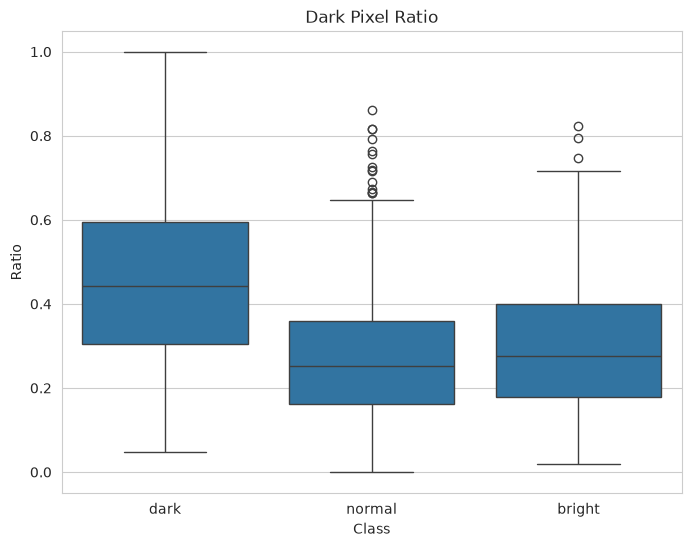

In [5]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="dark_ratio"
)

plt.title("Dark Pixel Ratio")
plt.xlabel("Class")
plt.ylabel("Ratio")

plt.show()

### Cell 5: Boxplot - Bright Pixel Ratio

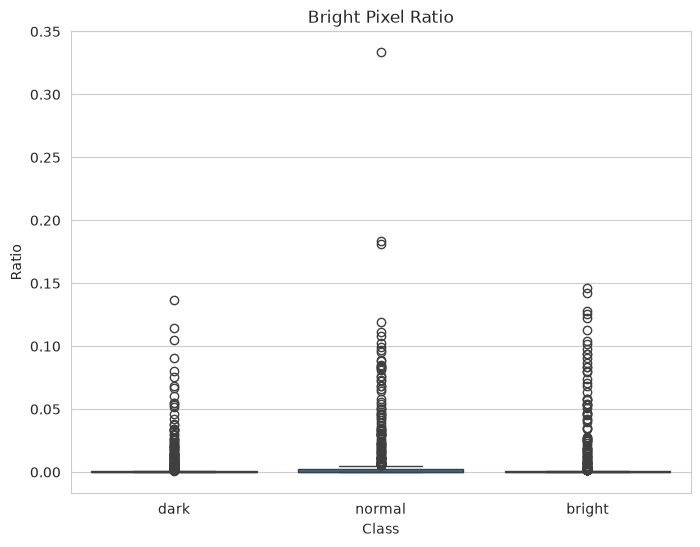

In [6]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="bright_ratio"
)

plt.title("Bright Pixel Ratio")
plt.xlabel("Class")
plt.ylabel("Ratio")

plt.show()

### Cell 6: Histogram - Mean Gray

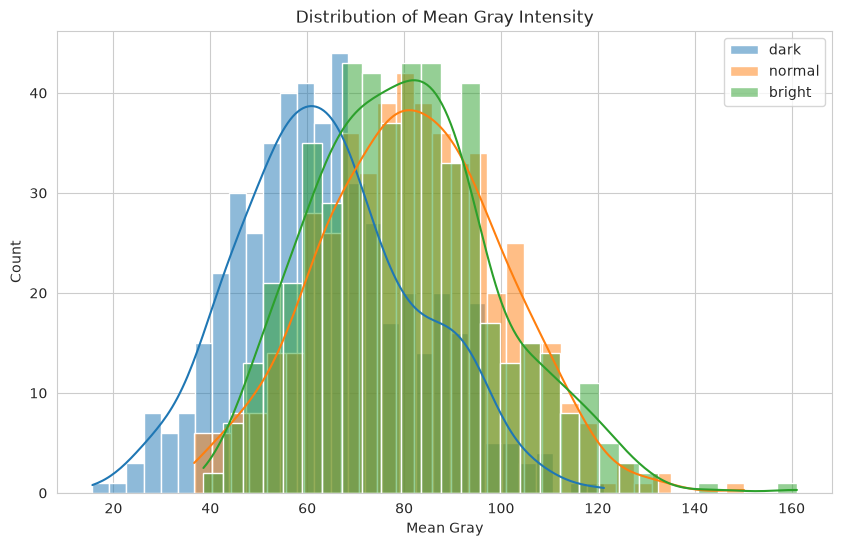

In [7]:
plt.figure(figsize=(10,6))

for cls in ["dark", "normal", "bright"]:

    sns.histplot(
        df[df["class"] == cls]["mean_gray"],
        bins=30,
        kde=True,
        label=cls,
        alpha=0.5
    )

plt.title("Distribution of Mean Gray Intensity")
plt.xlabel("Mean Gray")
plt.ylabel("Count")

plt.legend()

plt.show()

### Cell 7: Histogram - HSV Value

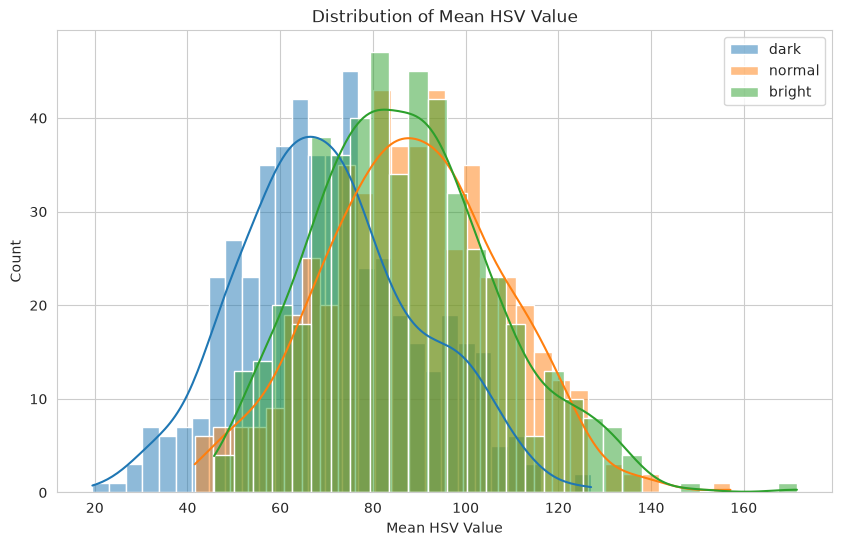

In [8]:
plt.figure(figsize=(10,6))

for cls in ["dark", "normal", "bright"]:

    sns.histplot(
        df[df["class"] == cls]["mean_value"],
        bins=30,
        kde=True,
        label=cls,
        alpha=0.5
    )

plt.title("Distribution of Mean HSV Value")
plt.xlabel("Mean HSV Value")
plt.ylabel("Count")

plt.legend()

plt.show()

### Cell 8: Pairplot

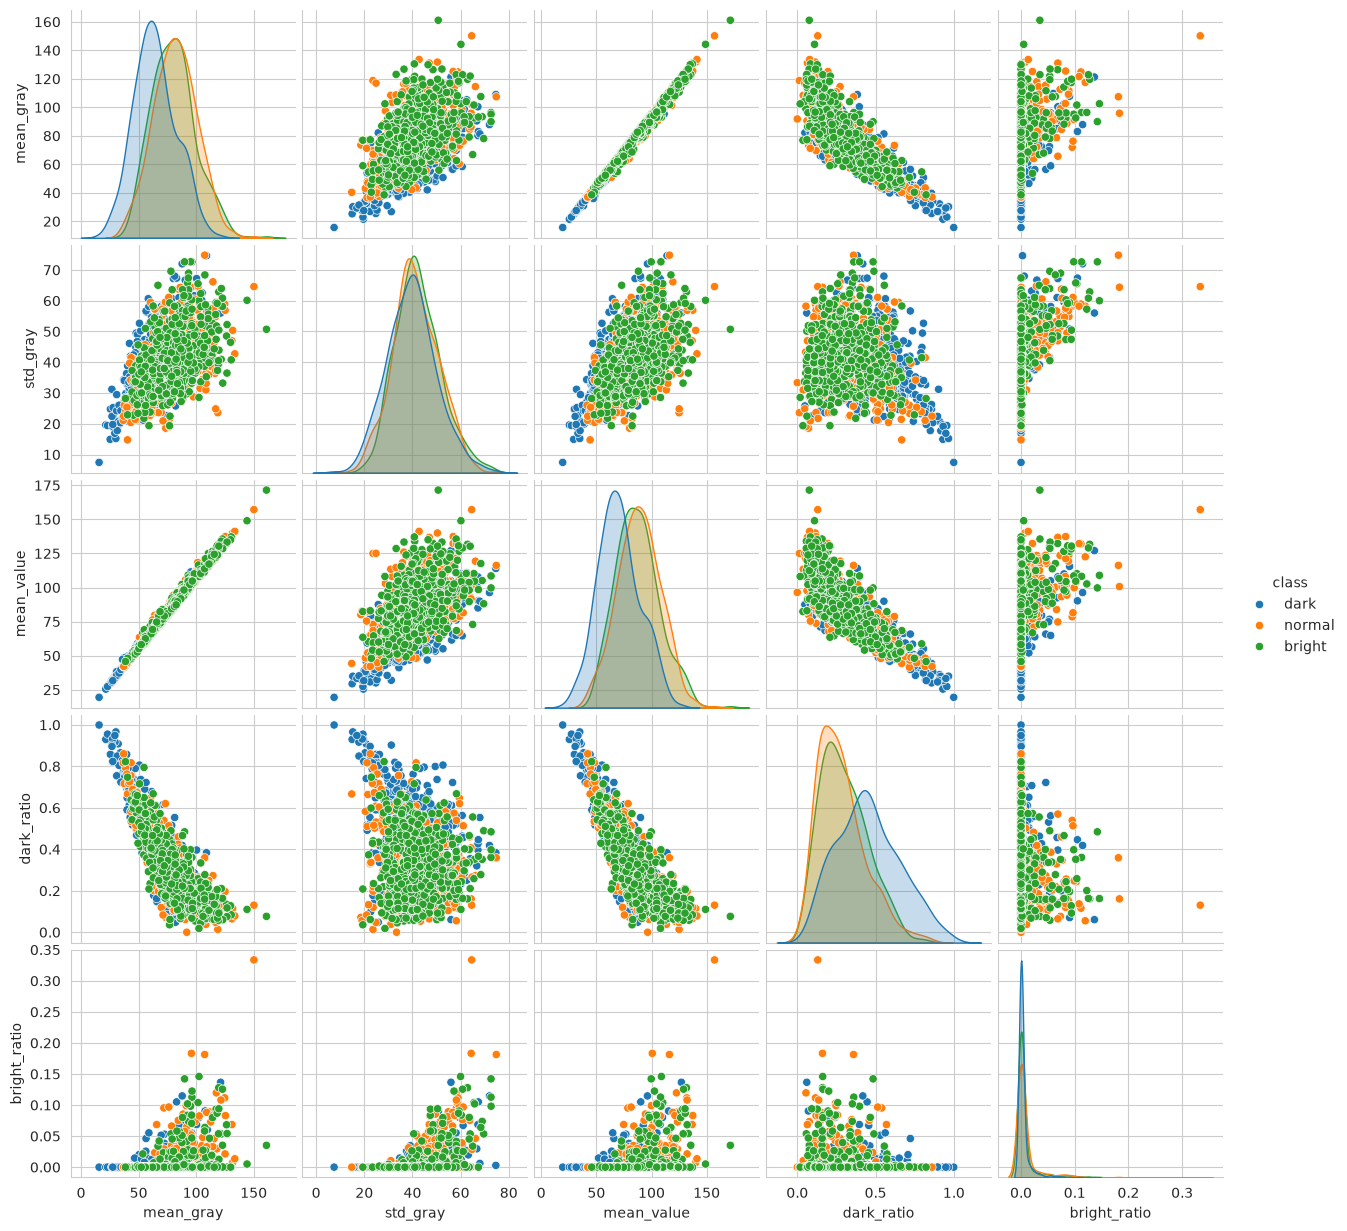

In [9]:
sns.pairplot(
    df,
    hue="class",
    vars=[
        "mean_gray",
        "std_gray",
        "mean_value",
        "dark_ratio",
        "bright_ratio"
    ],
    diag_kind="kde"
)

plt.show()

### Cell 9: Correlation Heatmap

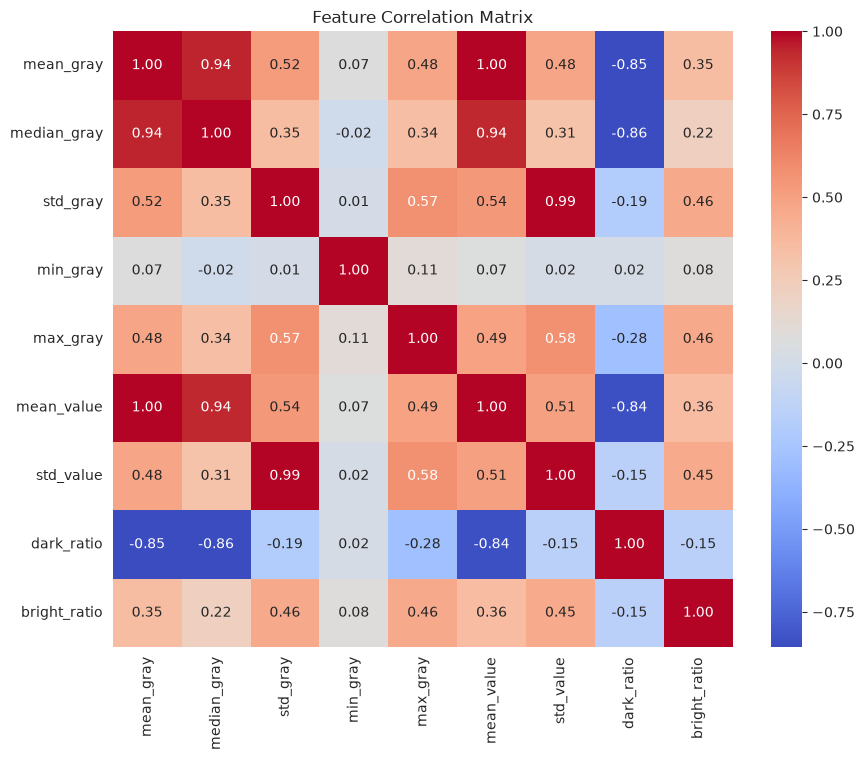

In [10]:
plt.figure(figsize=(10,8))

corr = df.drop(columns=["class"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

### Cell 10: Violin Plot

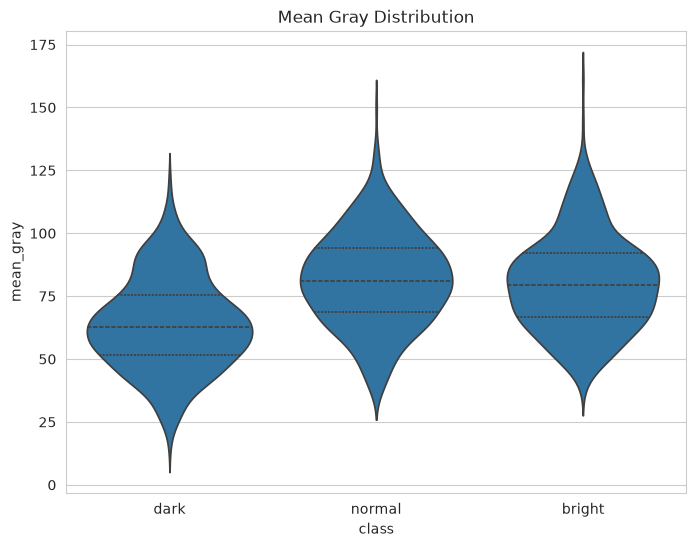

In [11]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="class",
    y="mean_gray",
    inner="quartile"
)

plt.title("Mean Gray Distribution")

plt.show()

### Cell 11: Class-wise Summary Statistics

In [12]:
summary = df.groupby("class").describe()

display(summary)

mean_gray                                                         \
           count       mean        std        min        25%        50%   
class                                                                     
bright     500.0  80.278295  18.939502  38.573395  66.871236  79.342815   
dark       500.0  64.031197  18.317973  15.653549  51.714128  62.824516   
normal     500.0  81.569505  18.658174  36.660919  68.559342  81.172192   

                              median_gray          ... dark_ratio            \
              75%         max       count    mean  ...        75%       max   
class                                              ...                        
bright  92.278393  161.094166       500.0  78.626  ...   0.399180  0.822426   
dark    75.396343  121.257156       500.0  58.291  ...   0.594397  0.999161   
normal  94.262065  150.180183       500.0  80.640  ...   0.358262  0.860172   

       bright_ratio                                                         
              count      mean       std  min  25%  50%       75%       max  
class                                                                       
bright        500.0  0.007205  0.021846  0.0  0.0  0.0  0.000478  0.145969  
dark          500.0  0.004512  0.014446  0.0  0.0  0.0  0.000473  0.136627  
normal        500.0  0.009035  0.027169  0.0  0.0  0.0  0.002109  0.333656  

[3 rows x 72 columns]

### The answers we got from the analysis 
Dark is clearly separable

From the Mean Gray boxplot and histogram:

Dark has a noticeably lower mean intensity.
The distribution is shifted to the left.
There is some overlap, but it's much smaller than with the other classes.

This matches your confusion matrix where dark has the highest recall (~70%).

Conclusion: The model has learned the dark class reasonably well.

## Next 
#### In the next analysis we want the answer of this question 
#### Does the "bright" class have higher contrast?
#### Is "normal" more saturated?
#### Does one class have sharper edges?
#### Are there hidden cues beyond brightness that a CNN could exploit?

In [2]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

from skimage.measure import shannon_entropy

In [3]:
DATASET_PATH = "data/train"

classes = ["dark", "normal", "bright"]

records = []

### Main Feature Extraction

In [4]:
for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    for file in tqdm(os.listdir(folder), desc=cls):

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        h = hsv[:,:,0]
        s = hsv[:,:,1]
        v = hsv[:,:,2]

        # ----------------------------
        # Brightness
        # ----------------------------

        mean_gray = gray.mean()

        median_gray = np.median(gray)

        std_gray = gray.std()

        min_gray = gray.min()

        max_gray = gray.max()

        # ----------------------------
        # Contrast
        # ----------------------------

        rms_contrast = gray.std()

        # ----------------------------
        # Entropy
        # ----------------------------

        entropy = shannon_entropy(gray)

        # ----------------------------
        # Sharpness
        # ----------------------------

        laplacian_var = cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()

        # ----------------------------
        # Edge Density
        # ----------------------------

        edges = cv2.Canny(gray,100,200)

        edge_density = np.mean(edges>0)

        # ----------------------------
        # HSV Statistics
        # ----------------------------

        mean_h = h.mean()

        mean_s = s.mean()

        mean_v = v.mean()

        # ----------------------------
        # Pixel Ratios
        # ----------------------------

        dark_ratio = np.mean(gray<50)

        bright_ratio = np.mean(gray>200)

        records.append({

            "class":cls,

            "mean_gray":mean_gray,

            "median_gray":median_gray,

            "std_gray":std_gray,

            "min_gray":min_gray,

            "max_gray":max_gray,

            "rms_contrast":rms_contrast,

            "entropy":entropy,

            "laplacian_var":laplacian_var,

            "edge_density":edge_density,

            "mean_h":mean_h,

            "mean_s":mean_s,

            "mean_v":mean_v,

            "dark_ratio":dark_ratio,

            "bright_ratio":bright_ratio

        })

bright: 100%|██████████| 500/500 [00:14<00:00, 35.16it/s]


In [5]:
feature_df = pd.DataFrame(records)

print(feature_df.shape)

feature_df.head()

(1500, 15)


,class,mean_gray,median_gray,std_gray,min_gray,max_gray,rms_contrast,entropy,laplacian_var,edge_density,mean_h,mean_s,mean_v,dark_ratio,bright_ratio
0,dark,96.133110,91.0,48.008489,6,232,48.008489,7.319002,281.944820,0.035538,27.287617,75.138744,104.939178,0.188370,0.055027
1,dark,100.391781,93.0,67.182270,10,231,67.182270,7.252165,290.972751,0.037601,67.238487,66.686905,107.824699,0.396275,0.068573
2,dark,58.453758,40.0,44.676709,4,194,44.676709,6.722094,247.539932,0.017616,65.054512,76.940178,66.517662,0.603424,0.000000
3,dark,51.079758,30.0,40.958746,7,209,40.958746,6.076134,256.691741,0.026901,68.018742,86.565586,56.650806,0.708744,0.000328
4,dark,53.586952,53.0,31.994654,0,182,31.994654,6.832577,212.315820,0.003983,51.874065,82.622356,58.008808,0.458103,0.000000


In [6]:
summary = feature_df.groupby("class").mean()

display(summary)

,mean_gray,median_gray,std_gray,min_gray,max_gray,rms_contrast,entropy,laplacian_var,edge_density,mean_h,mean_s,mean_v,dark_ratio,bright_ratio
class,,,,,,,,,,,,,,
bright,80.278295,78.626,42.254326,2.046,192.602,42.254326,7.028141,248.759654,0.027512,49.531822,79.837959,87.160791,0.299378,0.007205
dark,64.031197,58.291,39.622865,1.524,191.938,39.622865,6.807560,241.380215,0.022218,52.558138,89.921559,70.297366,0.453221,0.004512
normal,81.569505,80.640,41.293134,1.330,193.548,41.293134,7.011364,251.824650,0.029439,47.594135,79.520272,88.478030,0.281156,0.009035


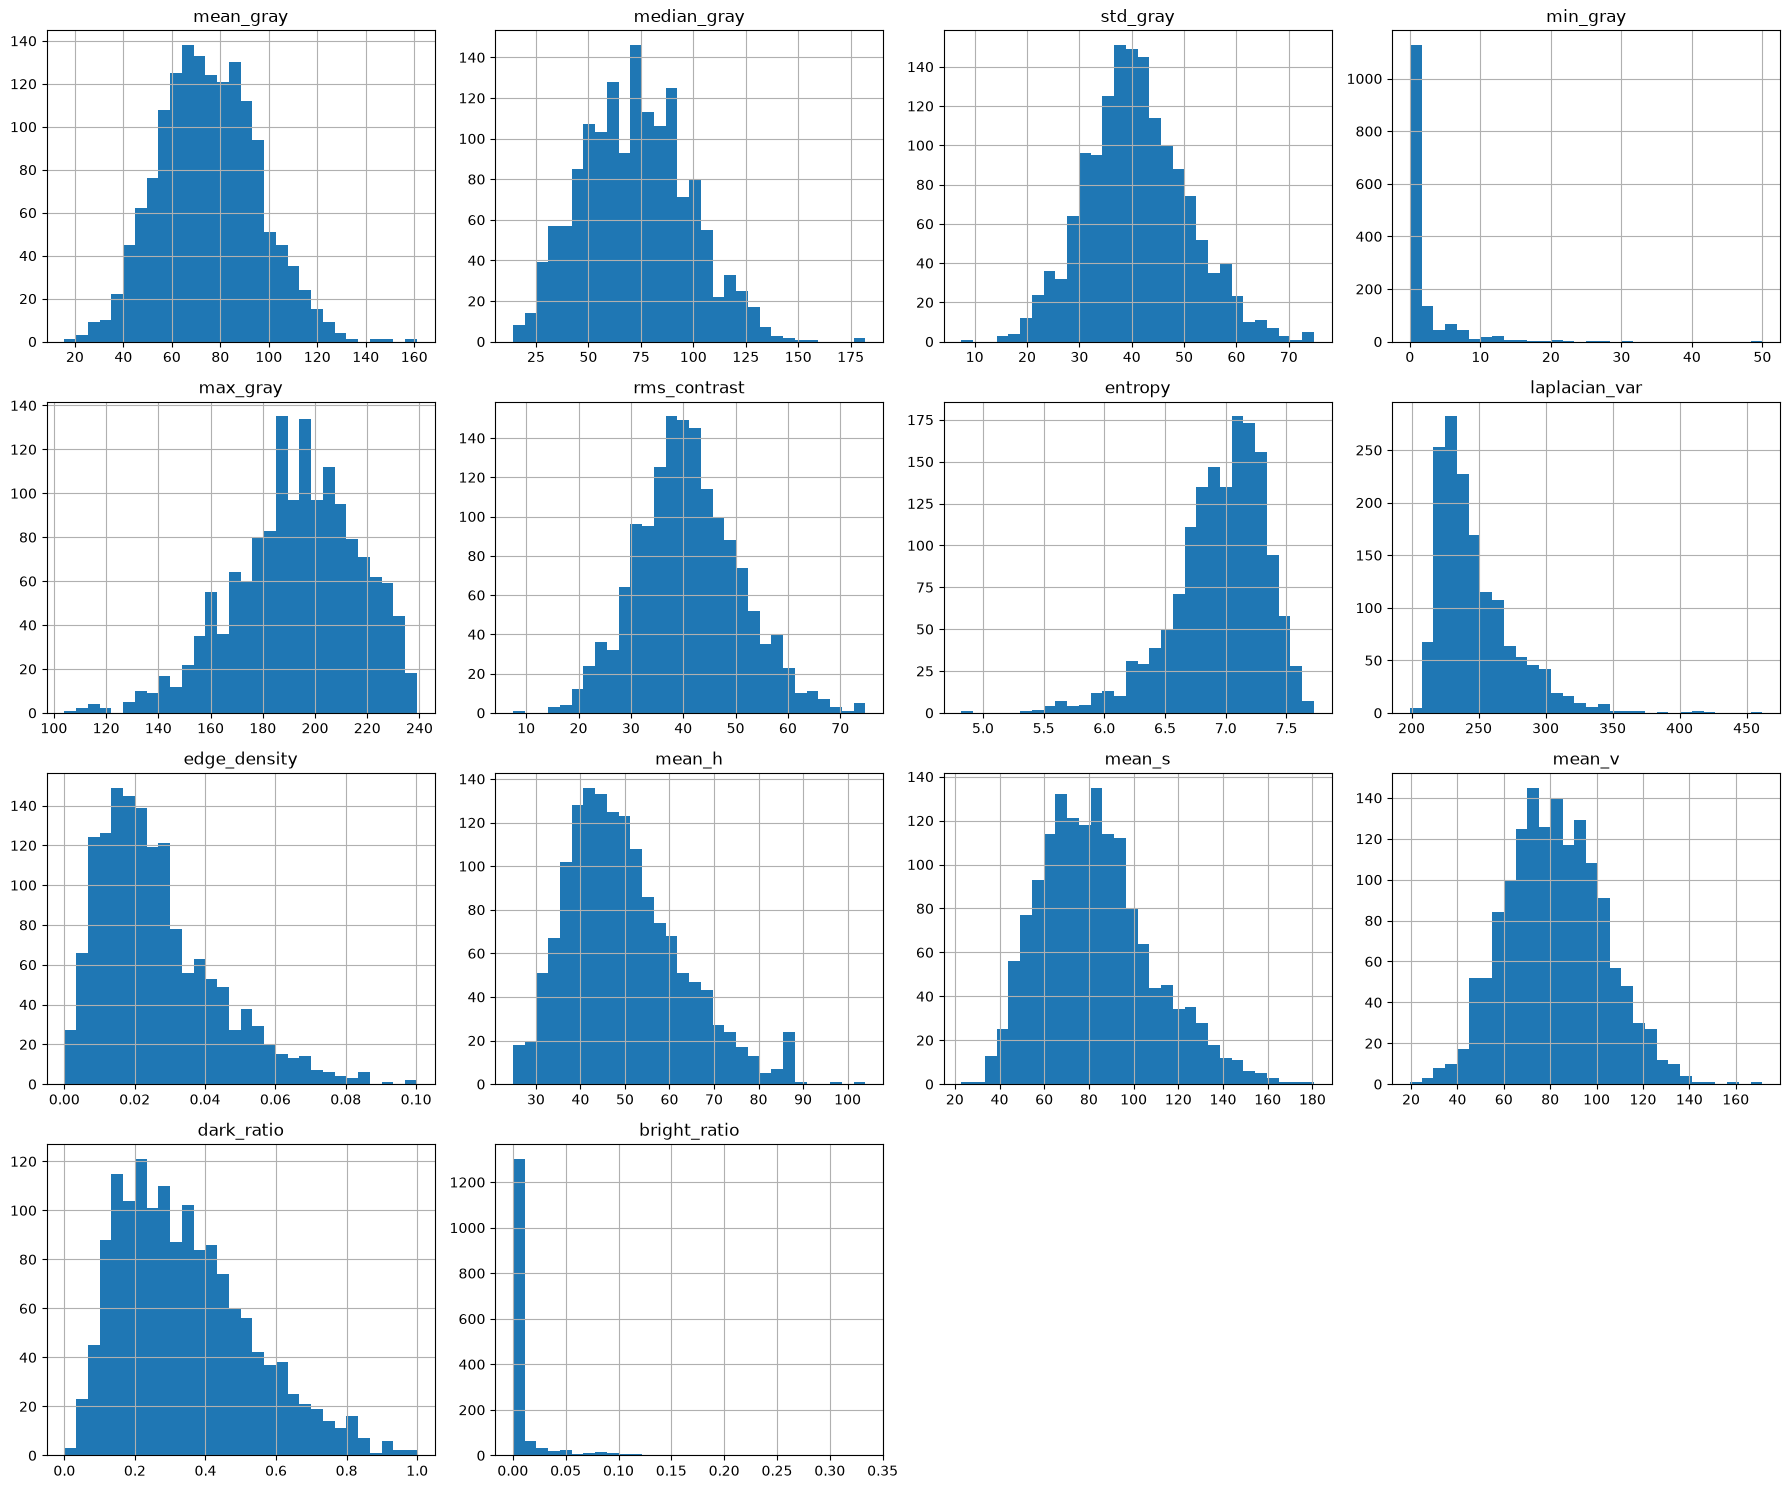

In [7]:
import matplotlib.pyplot as plt

feature_df.hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()

plt.show()

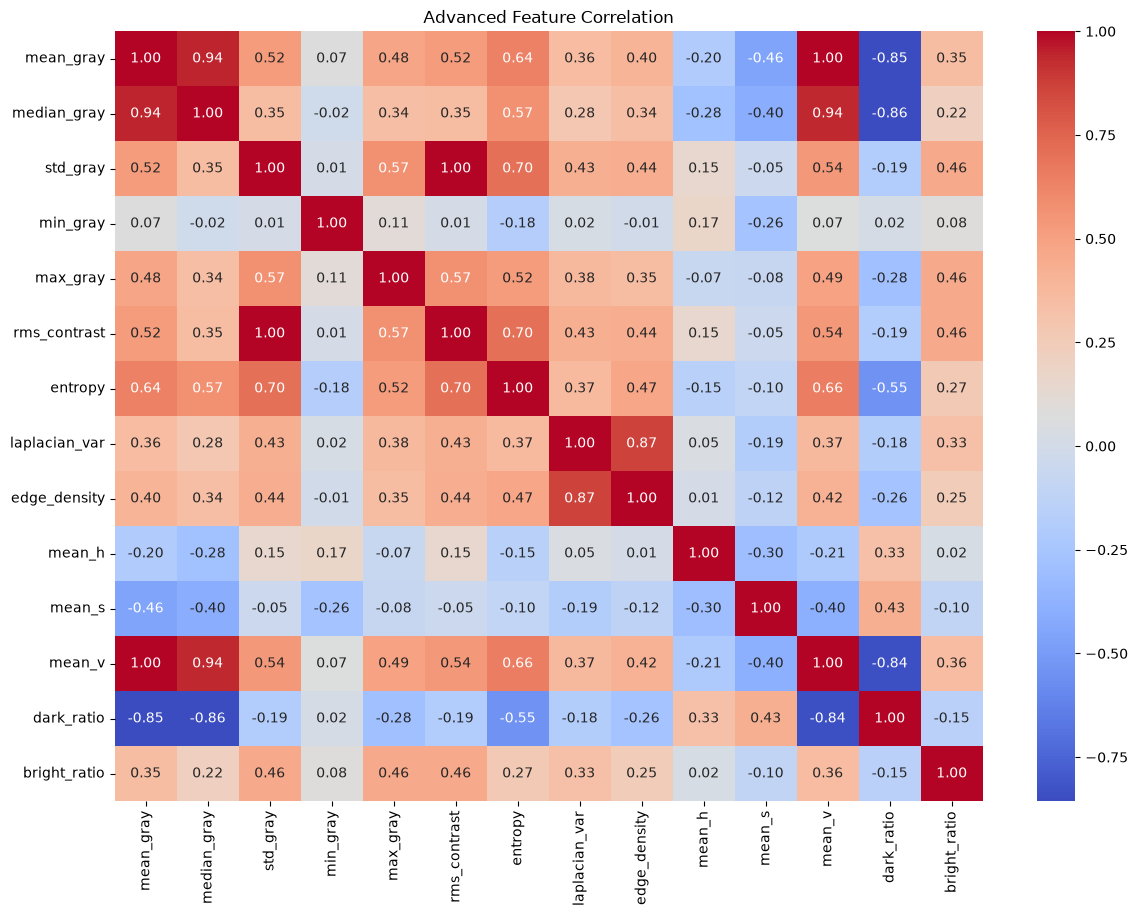

In [8]:
import seaborn as sns

plt.figure(figsize=(14,10))

corr = feature_df.drop(columns=["class"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Advanced Feature Correlation")

plt.show()

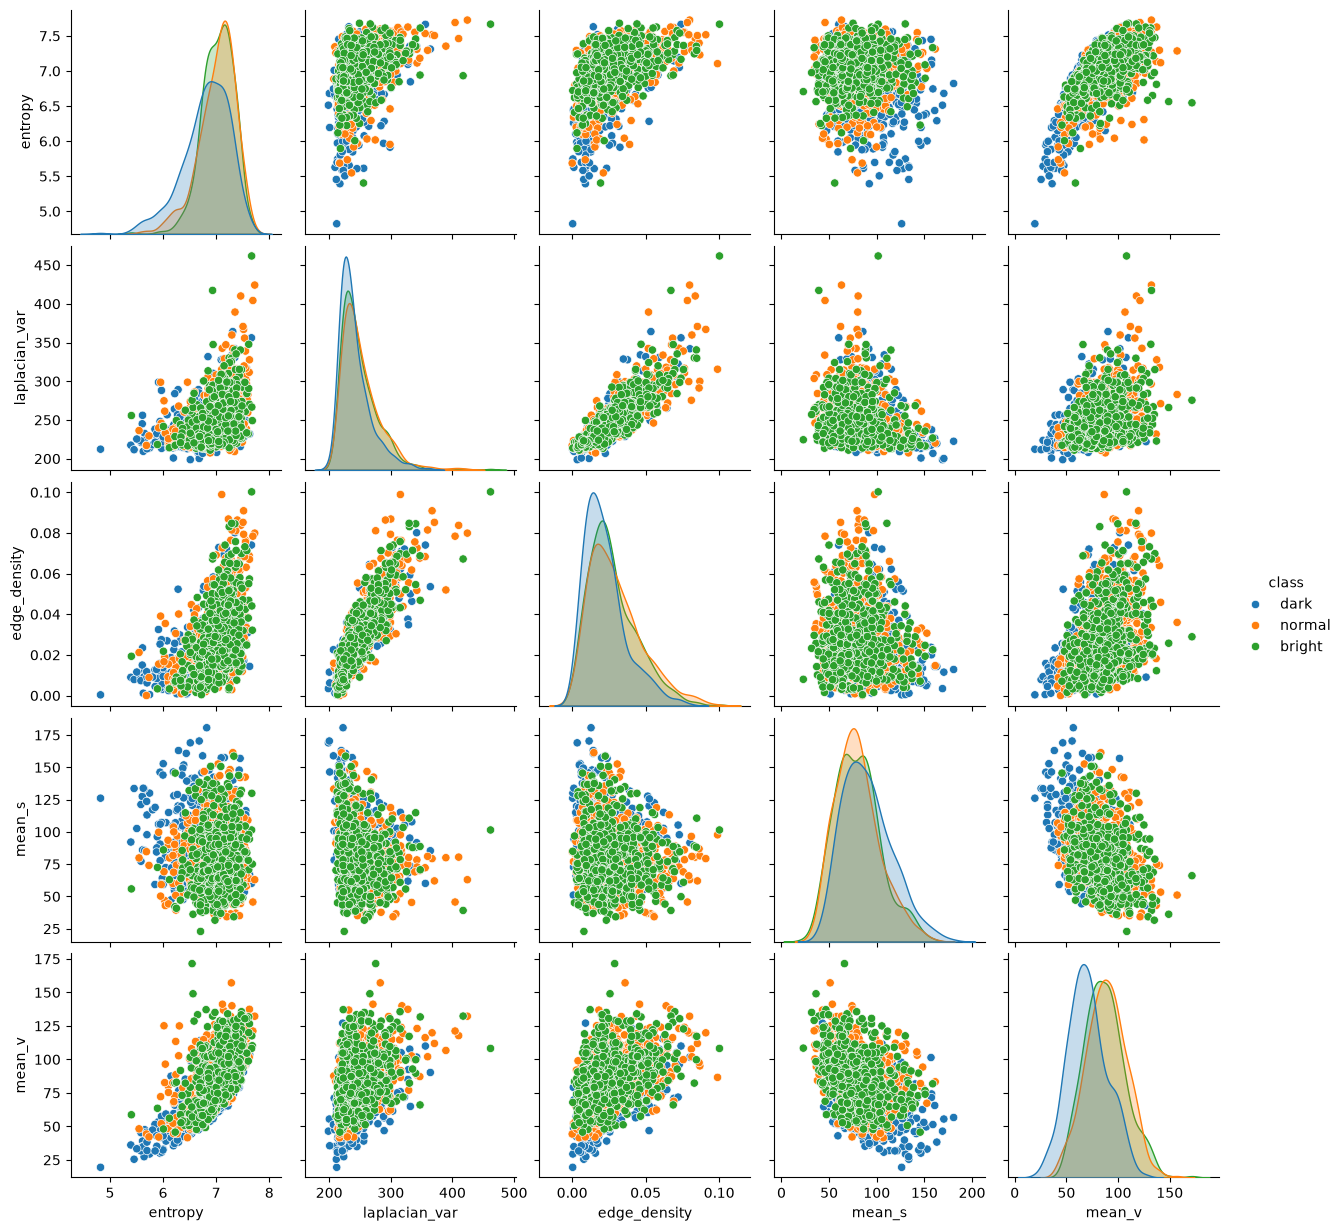

In [9]:
sns.pairplot(
    feature_df,
    hue="class",
    vars=[
        "entropy",
        "laplacian_var",
        "edge_density",
        "mean_s",
        "mean_v"
    ],
    diag_kind="kde"
)

plt.show()